In [1]:
import pandas as pd
import numpy as np

tech = pd.read_parquet("advanced_technical_features.parquet")
sent = pd.read_parquet("data_alt_features_2.parquet")


In [2]:
print("TECH")
print(tech.head())
print(tech.columns)
print(tech.shape)

print("\nSENT")
print(sent.head())
print(sent.columns)
print(sent.shape)

TECH
         date ticker    return      ma_20      ma_50  ma20_ma50_ratio  \
49 2018-10-09   AAPL  0.011503  52.721424  51.172302         1.030273   
50 2018-10-10   AAPL -0.046326  52.698113  51.280355         1.027647   
51 2018-10-11   AAPL -0.008828  52.586884  51.394602         1.023199   
52 2018-10-12   AAPL  0.035719  52.599190  51.550153         1.020350   
53 2018-10-15   AAPL -0.021386  52.492101  51.681428         1.015686   

    distance_to_ma20  rolling_20d_return    rsi_14  macd_12_26_9  \
49          0.018391            0.025169 -1.984656      0.658260   
50         -0.028358           -0.009023 -0.904276      0.450856   
51         -0.034898           -0.041992 -0.818099      0.247164   
52         -0.000659            0.004705 -1.096521      0.229371   
53         -0.020036           -0.039972 -0.987460      0.123142   

    macd_histogram    vol_20    atr_14  bollinger_pct_b  bollinger_width  \
49        0.007534  0.014203  3.639341         0.772799         0.06741

In [3]:
sent = sent.reset_index()
print(sent.columns)
print(sent.head())

Index(['Ticker', 'Timestamp', 'sent_mean', 'sent_std', 'news_count',
       'pct_strong_negative', 'sent_momentum'],
      dtype='object')
  Ticker  Timestamp  sent_mean  sent_std  news_count  pct_strong_negative  \
0   AAPL 2026-04-04  -0.157758  0.345141         5.0                 20.0   
1    AMD 2026-04-04   0.449302  0.412799         3.0                  0.0   
2   AMZN 2026-04-04   0.084157  0.352984        13.0                  0.0   
3   BABA 2026-04-04   0.175880  0.000000         1.0                  0.0   
4    BAC 2026-04-04  -0.362722  0.297493         2.0                  0.0   

   sent_momentum  
0      -0.066902  
1       0.353329  
2      -0.036732  
3            NaN  
4      -0.407615  


In [4]:
sent = sent.rename(columns={
    "Ticker": "ticker",
    "Timestamp": "date"
})

sent["date"] = pd.to_datetime(sent["date"]).dt.normalize()
tech["date"] = pd.to_datetime(tech["date"]).dt.normalize()

sent["ticker"] = sent["ticker"].astype(str).str.upper().str.strip()
tech["ticker"] = tech["ticker"].astype(str).str.upper().str.strip()

In [7]:
print("Tech duplicate keys:", tech.duplicated(["date", "ticker"]).sum())
print("Sent duplicate keys:", sent.duplicated(["date", "ticker"]).sum())

Tech duplicate keys: 0
Sent duplicate keys: 0


In [8]:
final_df = tech.merge(sent, on=["date", "ticker"], how="left")

In [11]:
final_df.head()

,date,ticker,return,ma_20,ma_50,ma20_ma50_ratio,distance_to_ma20,rolling_20d_return,rsi_14,macd_12_26_9,...,vol_20,atr_14,bollinger_pct_b,bollinger_width,volume_zscore_20,sent_mean,sent_std,news_count,pct_strong_negative,sent_momentum
0,2018-10-09,AAPL,0.011503,52.721424,51.172302,1.030273,0.018391,0.025169,-1.984656,0.658260,...,0.014203,3.639341,0.772799,0.067415,-0.463602,NaN,NaN,NaN,NaN,NaN
1,2018-10-10,AAPL,-0.046326,52.698113,51.280355,1.027647,-0.028358,-0.009023,-0.904276,0.450856,...,0.017521,3.567729,0.095253,0.070062,0.464224,NaN,NaN,NaN,NaN,NaN
2,2018-10-11,AAPL,-0.008828,52.586884,51.394602,1.023199,-0.034898,-0.041992,-0.818099,0.247164,...,0.016531,3.597367,0.048878,0.077358,1.064316,NaN,NaN,NaN,NaN,NaN
3,2018-10-12,AAPL,0.035719,52.599190,51.550153,1.020350,-0.000659,0.004705,-1.096521,0.229371,...,0.018341,3.674346,0.491462,0.077193,0.330697,NaN,NaN,NaN,NaN,NaN
4,2018-10-15,AAPL,-0.021386,52.492101,51.681428,1.015686,-0.020036,-0.039972,-0.987460,0.123142,...,0.018061,3.647577,0.241942,0.077641,-0.218202,NaN,NaN,NaN,NaN,NaN


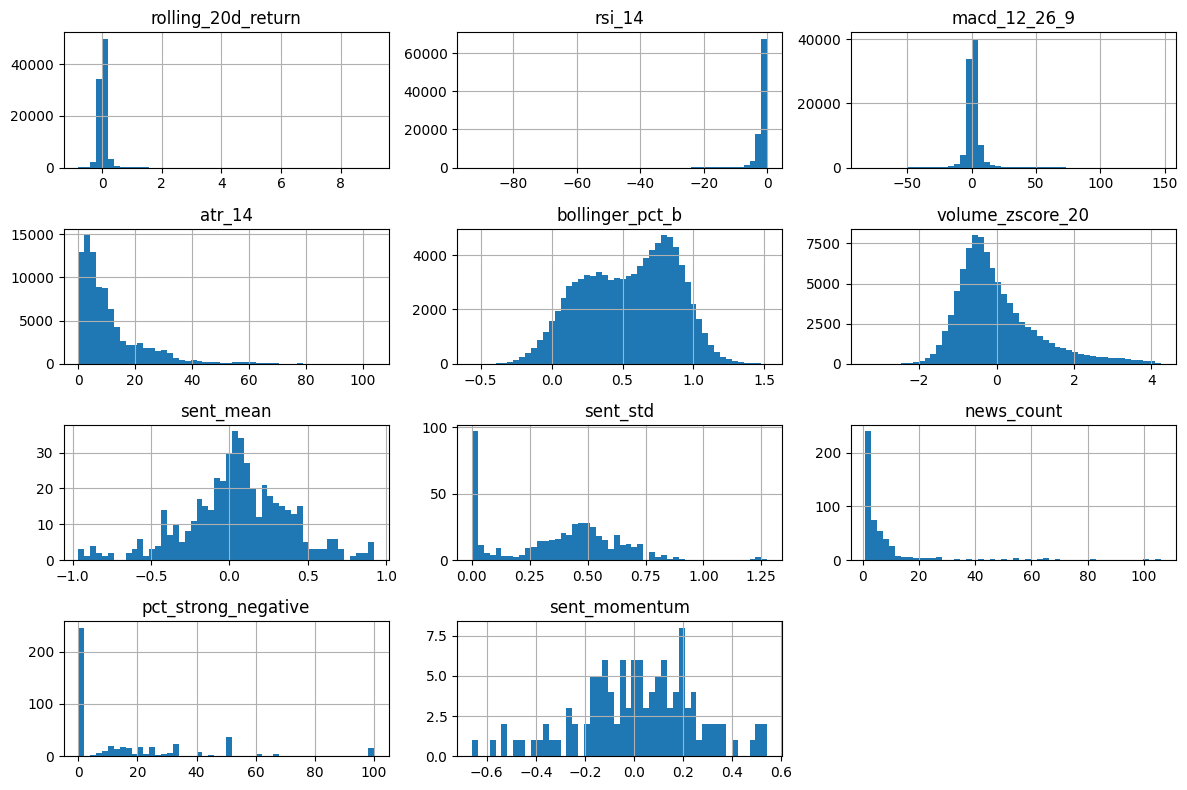

In [13]:
import matplotlib.pyplot as plt

cols = [
    "rolling_20d_return","rsi_14","macd_12_26_9",
    "atr_14","bollinger_pct_b","volume_zscore_20",
    "sent_mean","sent_std","news_count","pct_strong_negative","sent_momentum"
]

final_df[cols].hist(bins=50, figsize=(12,8))
plt.tight_layout()
plt.show()

In [14]:
sent_cols = ["sent_mean","sent_std","news_count","pct_strong_negative","sent_momentum"]

# unique counts
print(final_df[sent_cols].nunique())

# std (should be > 0)
print(final_df[sent_cols].std())

sent_mean              469
sent_std               383
news_count              42
pct_strong_negative     56
sent_momentum          117
dtype: int64
sent_mean               0.333305
sent_std                0.256057
news_count             12.079892
pct_strong_negative    23.283296
sent_momentum           0.240922
dtype: float64


In [ ]:
final_df.to_parquet("../../